In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [3]:
test = pd.read_csv('/kaggle/input/sentiment-analysis-10/test.csv')
test.head()

,IDs,Unnamed: 0,ID,comments,votes
0,1,0,3163731718,一包纸不够,3
1,2,1,3195259753,这段时间的几部原创作品的本土性都很好（坐等OST），这部如果有粤语版会再看一遍~~《矮婆》是...,0
2,3,2,3151446187,虽然套路，但励志，适合陪孩子看,1
3,4,3,3152887290,东西就怕货比货，想想今年看的国产片都那样，还是打个五星吧，就这还被说乳化也是离谱到家了。电影...,0
4,5,4,3144942661,4.5。聚焦文化传统舞狮，本广东人看得莫名的怀念。庙会，舞狮，以及鼓点，一切都是那么熟悉。总...,2


In [4]:
train = pd.read_csv('/kaggle/input/sentiment-analysis-10/train.csv')
train.head()

,IDs,Unnamed: 0,ID,comments,rating,votes
0,1,0,3144518654,虽然套路，但，真的好燃啊！！！后半段各种热泪瞬间。结尾收得很好，不用真的给一个奇迹瞬间，足够...,4,6845
1,2,1,3132673708,终于看到一部不是以孙悟空、哪吒为主角的优秀国漫了，居然还是现实主义题材的，太惊喜了。画风写实...,5,6375
2,3,2,3141125920,说句公道话，片方赚的每一分钱都应该拿出一半给周星驰，拿出两成给徐克李连杰，再拿出一成给马东。...,3,2968
3,4,3,3141155105,前半段配音烂、节奏烂、笑料烂，后半段老子一顿暴哭，燃死我得了，真的太顶了，简直是一杯呛鼻的烈...,4,5295
4,5,4,3136815531,是目前无限接近我心里当下该有的国漫样子——没有IP、没有过多对日美漫画的模仿、没有太多套路。...,5,7450


In [5]:
combined = pd.concat([train,test])
combined.head()

,IDs,Unnamed: 0,ID,comments,rating,votes
0,1,0,3144518654,虽然套路，但，真的好燃啊！！！后半段各种热泪瞬间。结尾收得很好，不用真的给一个奇迹瞬间，足够...,4.0,6845
1,2,1,3132673708,终于看到一部不是以孙悟空、哪吒为主角的优秀国漫了，居然还是现实主义题材的，太惊喜了。画风写实...,5.0,6375
2,3,2,3141125920,说句公道话，片方赚的每一分钱都应该拿出一半给周星驰，拿出两成给徐克李连杰，再拿出一成给马东。...,3.0,2968
3,4,3,3141155105,前半段配音烂、节奏烂、笑料烂，后半段老子一顿暴哭，燃死我得了，真的太顶了，简直是一杯呛鼻的烈...,4.0,5295
4,5,4,3136815531,是目前无限接近我心里当下该有的国漫样子——没有IP、没有过多对日美漫画的模仿、没有太多套路。...,5.0,7450


In [6]:
combined.infer_objects()

,IDs,Unnamed: 0,ID,comments,rating,votes
0,1,0,3144518654,虽然套路，但，真的好燃啊！！！后半段各种热泪瞬间。结尾收得很好，不用真的给一个奇迹瞬间，足够...,4.0,6845
1,2,1,3132673708,终于看到一部不是以孙悟空、哪吒为主角的优秀国漫了，居然还是现实主义题材的，太惊喜了。画风写实...,5.0,6375
2,3,2,3141125920,说句公道话，片方赚的每一分钱都应该拿出一半给周星驰，拿出两成给徐克李连杰，再拿出一成给马东。...,3.0,2968
3,4,3,3141155105,前半段配音烂、节奏烂、笑料烂，后半段老子一顿暴哭，燃死我得了，真的太顶了，简直是一杯呛鼻的烈...,4.0,5295
4,5,4,3136815531,是目前无限接近我心里当下该有的国漫样子——没有IP、没有过多对日美漫画的模仿、没有太多套路。...,5.0,7450
...,...,...,...,...,...,...
3709,3710,3709,2889815995,新瓶装旧酒，画面表演都很优秀，就是故事太旧，离戏曲电影还差点意思,NaN,0
3710,3711,3710,2921510650,给创新的艺术形式打五星,NaN,0
3711,3712,3711,2886587140,值得鼓励，建议去电影院看，在家里坐不住。曾老师真的好美，好有味道～,NaN,1
3712,3713,3712,2910974492,戏曲和CG好配,NaN,0


In [8]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11958 entries, 0 to 3713
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IDs         11958 non-null  int64  
 1   Unnamed: 0  11958 non-null  int64  
 2   ID          11958 non-null  int64  
 3   comments    11958 non-null  object 
 4   rating      8244 non-null   float64
 5   votes       11958 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 654.0+ KB


In [10]:
combined.dtypes

IDs             int64
Unnamed: 0      int64
ID              int64
comments       object
rating        float64
votes           int64
dtype: object

In [12]:
combined.isnull().sum()/len(combined)*100

IDs            0.000000
Unnamed: 0     0.000000
ID             0.000000
comments       0.000000
rating        31.058705
votes          0.000000
dtype: float64

In [13]:
combined.shape

(11958, 6)

In [15]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

IDs                3759.5
Unnamed: 0         3759.5
ID            255278153.0
rating                2.0
votes                 6.0
dtype: float64


/tmp/ipykernel_32/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_32/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_32/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [16]:
UL=Q3+(1.5*IQR)
LL=Q1-(1.5*IQR)

In [17]:
combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]

/tmp/ipykernel_32/1551434999.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]


In [18]:
combined_new.shape

(10054, 6)

<Axes: >

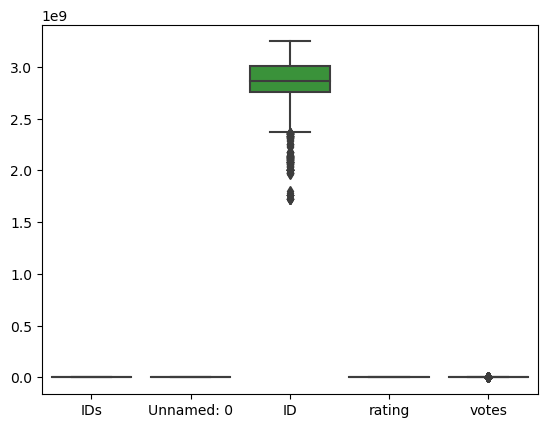

In [19]:
sns.boxplot(combined)

<Axes: >

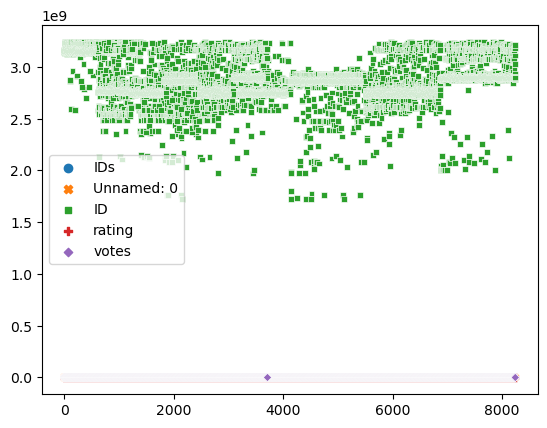

In [23]:
sns.scatterplot(combined)

<Axes: >

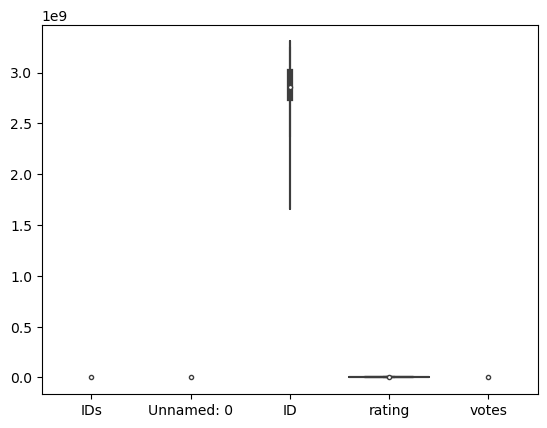

In [24]:
sns.violinplot(combined)

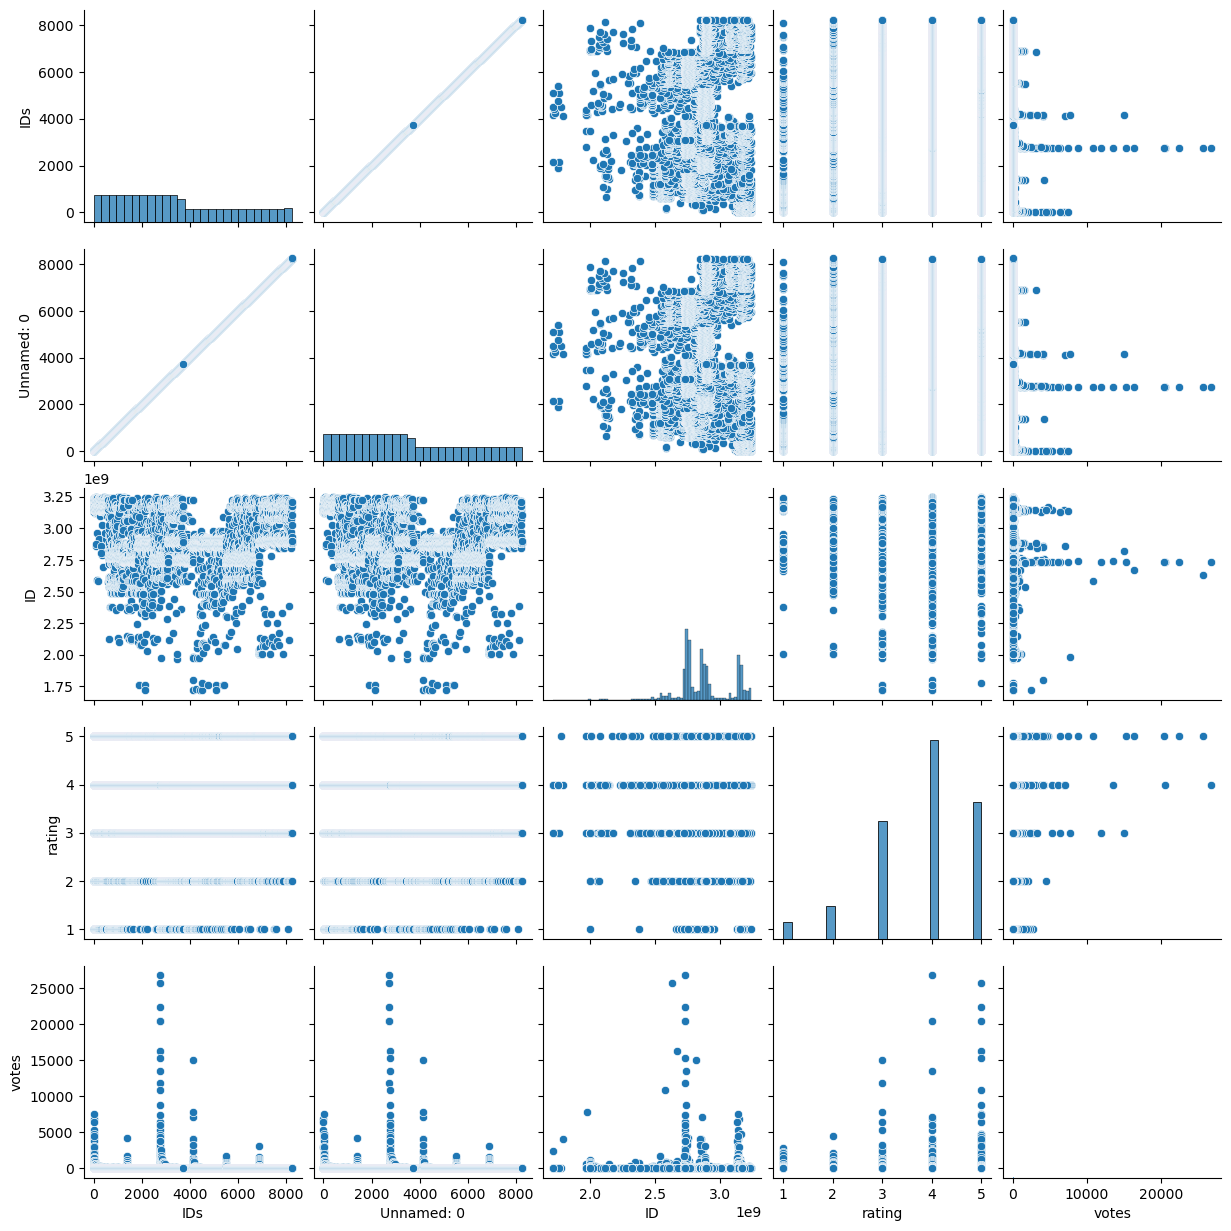

In [29]:
sns.pairplot(combined)

<Axes: ylabel='Density'>

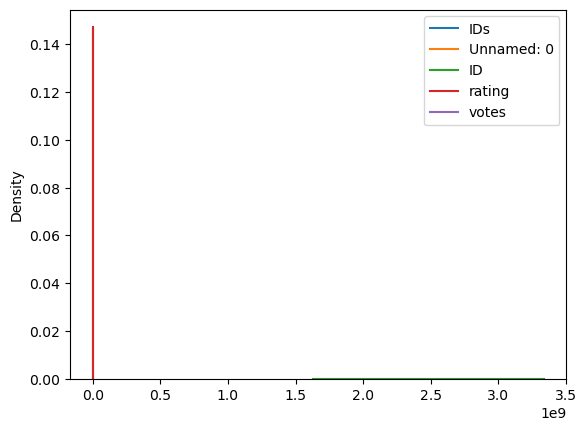

In [26]:
sns.kdeplot(combined)

In [27]:
combined.kurt()

/tmp/ipykernel_32/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


IDs            -0.933222
Unnamed: 0     -0.933222
ID              1.979878
rating          0.237707
votes         903.975815
dtype: float64

In [28]:
combined.skew()

/tmp/ipykernel_32/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


IDs            0.453364
Unnamed: 0     0.453364
ID            -0.341879
rating        -0.703027
votes         27.430523
dtype: float64

/tmp/ipykernel_32/4119637582.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


<Axes: >

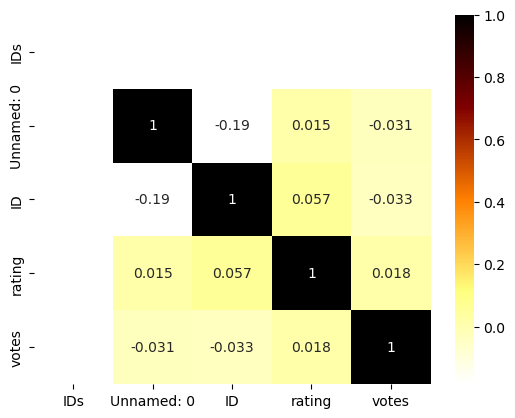

In [32]:
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')

In [30]:
combined['IDs']=combined['IDs'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_32/1366933530.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


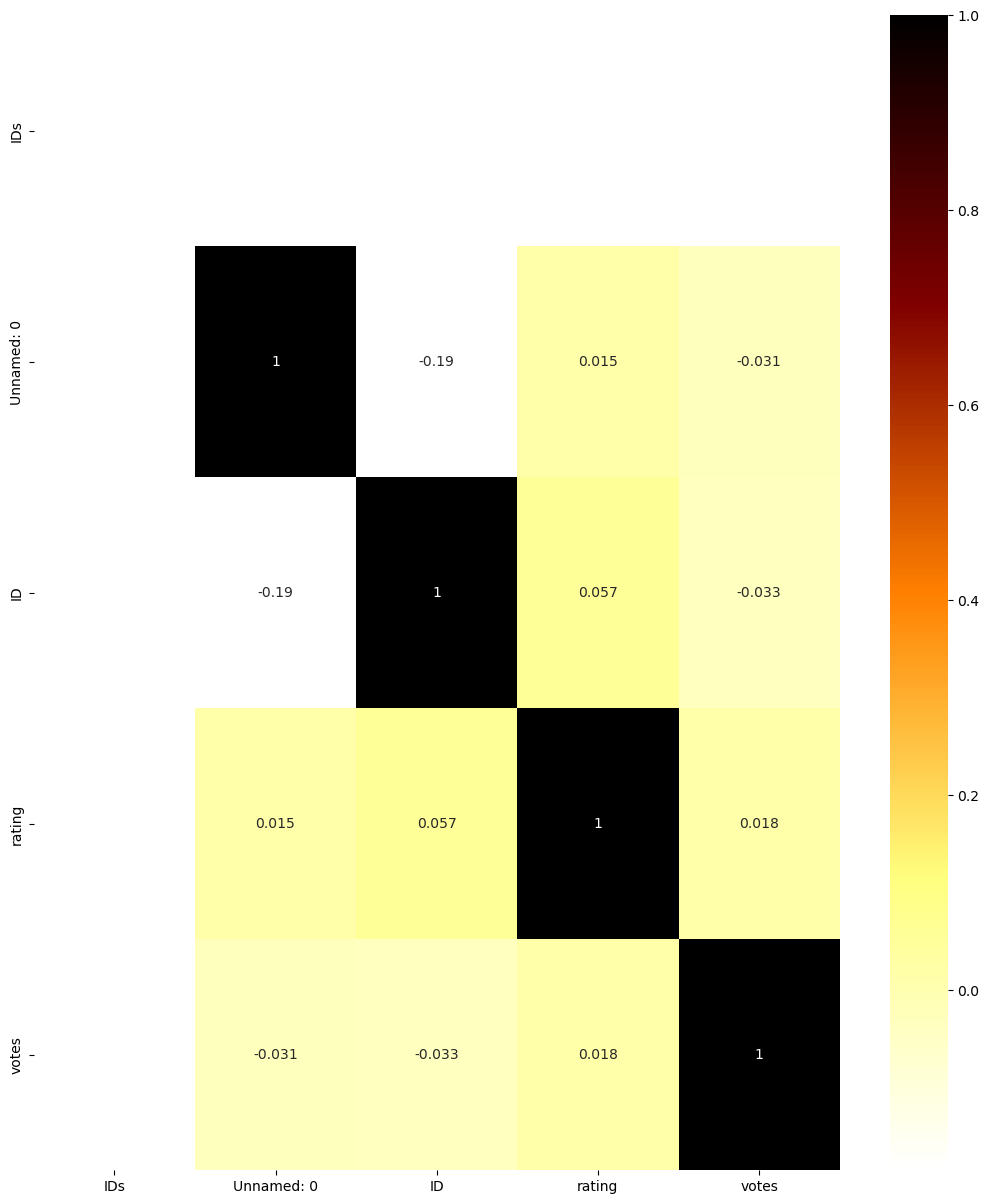

In [31]:
plt.figure(figsize=(13,15))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

In [6]:
cat_cols = combined.select_dtypes(include='object')

In [7]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

comments
说得够多了。不经反思的情绪跟灵气。他为何不伟大，就是不主动寻找答案。杨德昌的意图不见了。台湾电影的小打小闹。（我想看这部电影 2020-09-30 ）                             2
放过自己 | 林小姐，演的真好。英文片名 little big woman 赞！| 7 (豆瓣到底什么时候可以十分制打分...)                                        2
时间是与自己和解的良药。                                                                                            2
适合过年全家一起看                                                                                               2
5.5。不疼不痒，平庸之作。                                                                                          2
                                                                                                       ..
很稚嫩的导演，很真挚的感情\n事先知道贾玲的故事，看到电影里她的再次讲述就觉得她是把自己的心剖给观众看\n李焕英妈妈，贾玲真的成功了！                                     1
为母则刚\n天要下雨  粮要解营\n题外话：这个比唐探3笑点更高级、更多                                                                    1
整个电影院都在哭。每一个人都在哭。每一个。\n\n贾玲厉害。                                                                          1
视角没有偏颇吧，李焕英的形象本就来自女儿对母亲的记忆修正，实际上，所有的电

In [8]:
num_cols = combined.select_dtypes(include='number')

In [9]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

IDs
1       2
2482    2
2470    2
2471    2
2472    2
       ..
5230    1
5231    1
5232    1
5233    1
8244    1
Name: IDs, Length: 8244, dtype: int64
__________________________________________________
Unnamed: 0
0       2
2481    2
2469    2
2470    2
2471    2
       ..
5229    1
5230    1
5231    1
5232    1
8243    1
Name: Unnamed: 0, Length: 8244, dtype: int64
__________________________________________________
ID
2759273319    2
2761342654    2
2595878180    2
3239338946    2
2743417204    2
             ..
2748433052    1
2766013081    1
2757595093    1
2748828134    1
2892348236    1
Name: ID, Length: 8713, dtype: int64
__________________________________________________
rating
4.0    3361
5.0    2107
3.0    2019
2.0     522
1.0     235
Name: rating, dtype: int64
__________________________________________________
votes
0       4795
1       1900
2        887
3        562
4        416
        ... 
2765       1
4532       1
2517       1
7444       1
136        1
Name: votes, Length

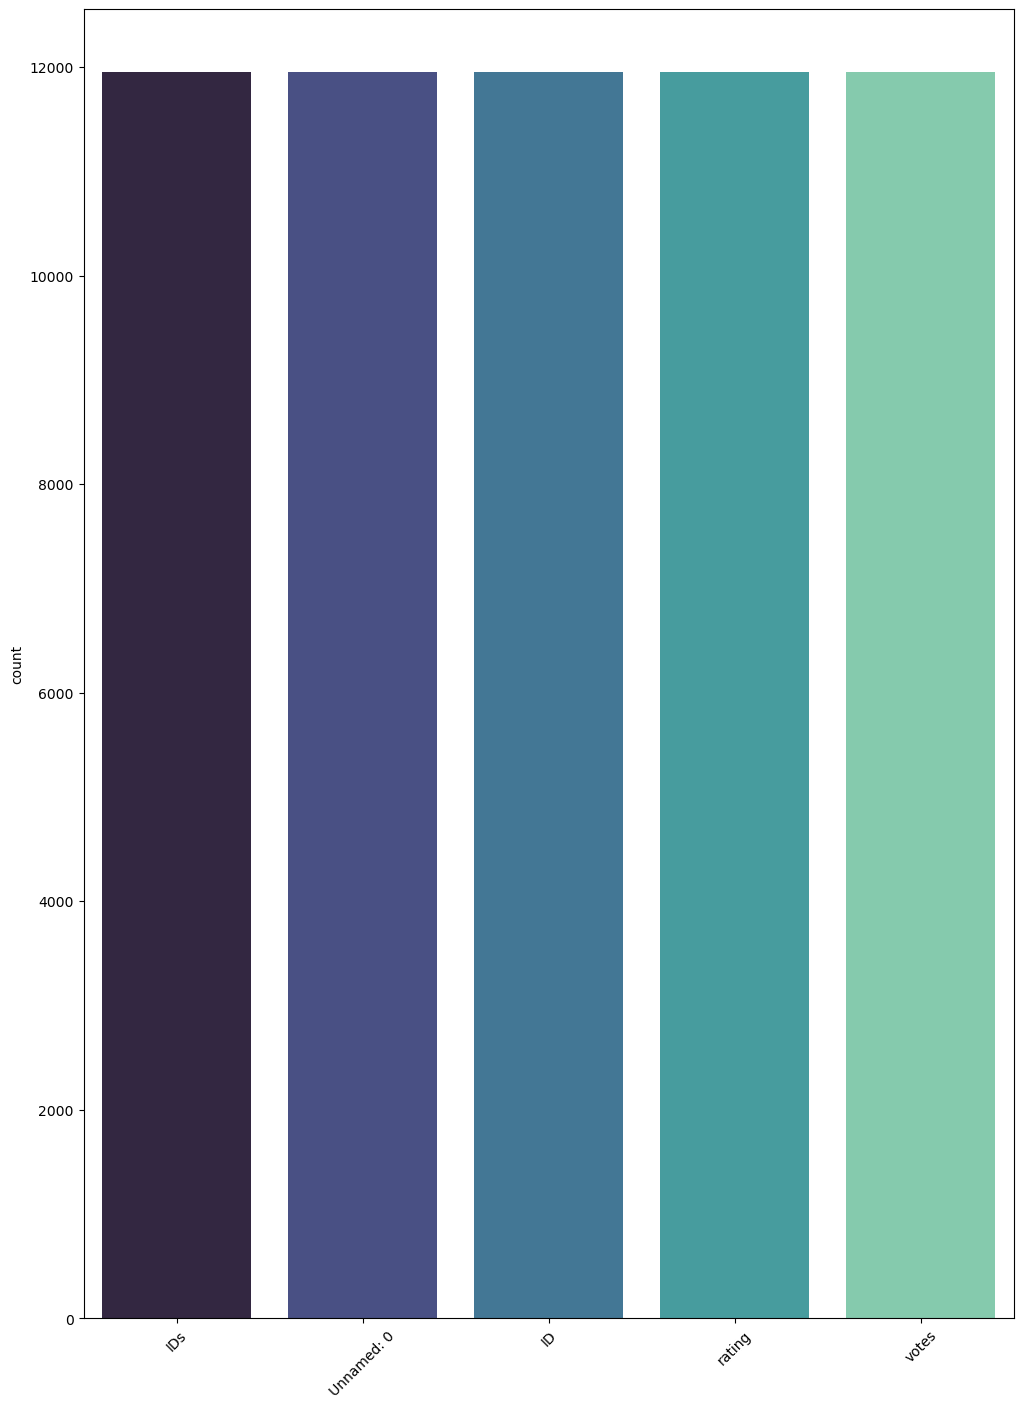

In [38]:
plt.figure(figsize=(12,17))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=45);

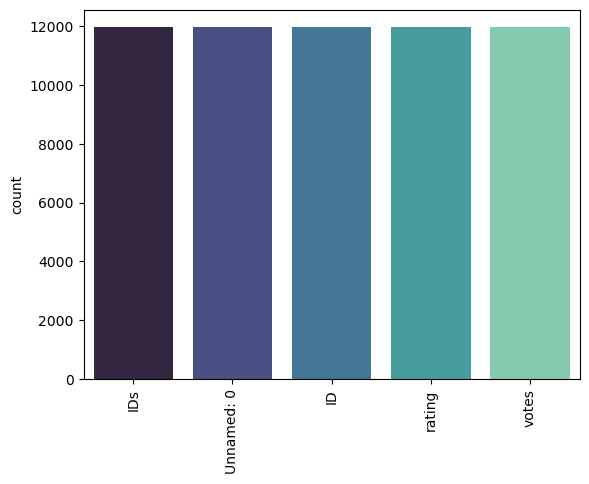

In [39]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'IDs'),
  Text(1, 0, 'Unnamed: 0'),
  Text(2, 0, 'ID'),
  Text(3, 0, 'rating'),
  Text(4, 0, 'votes')])

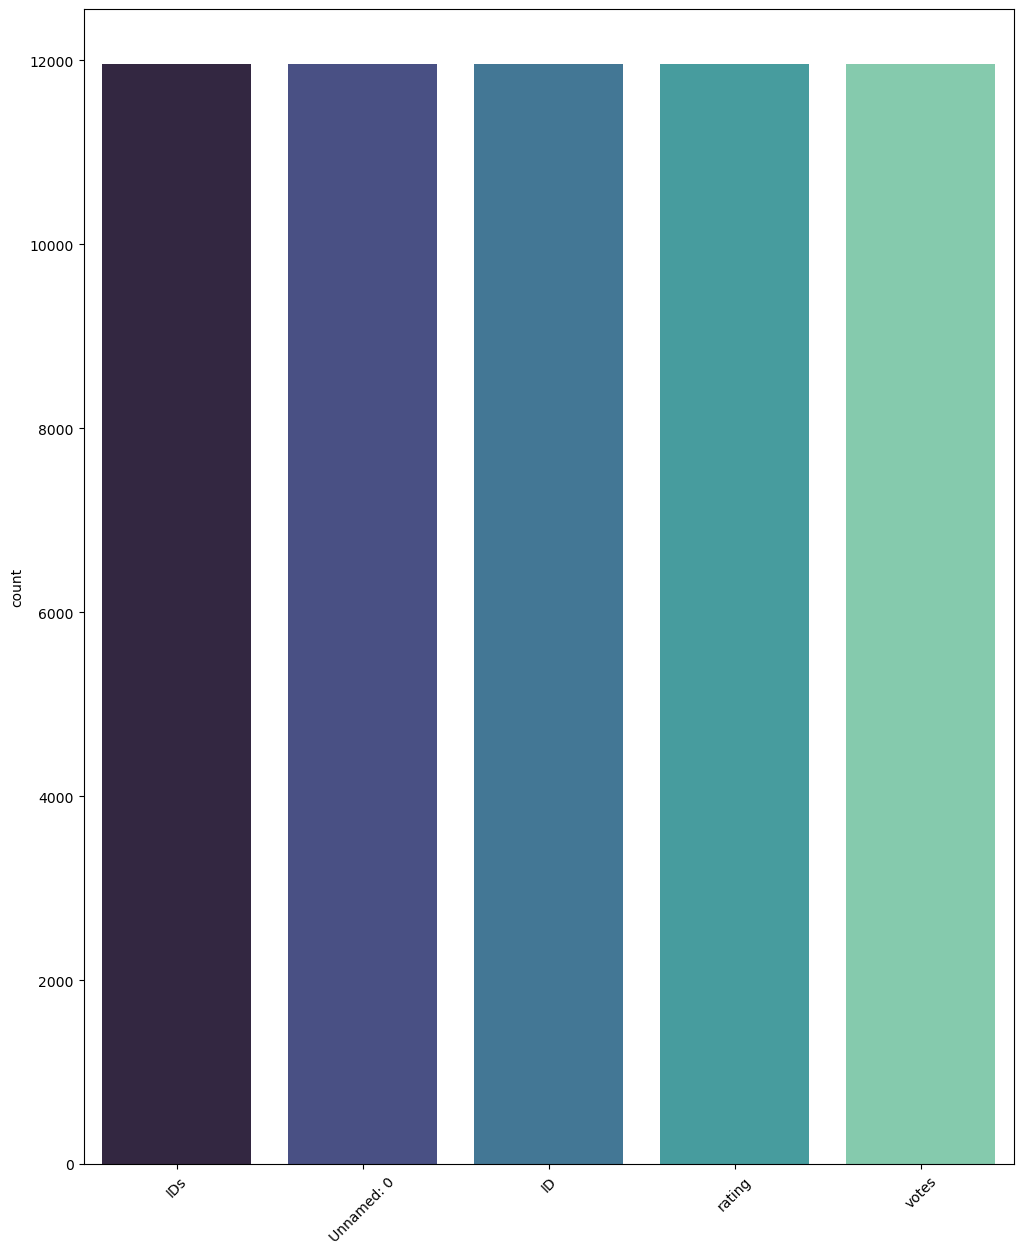

In [40]:
plt.figure(figsize=(12,15))
sns.countplot(combined,palette='mako')
plt.xticks(rotation=45)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


<Axes: >

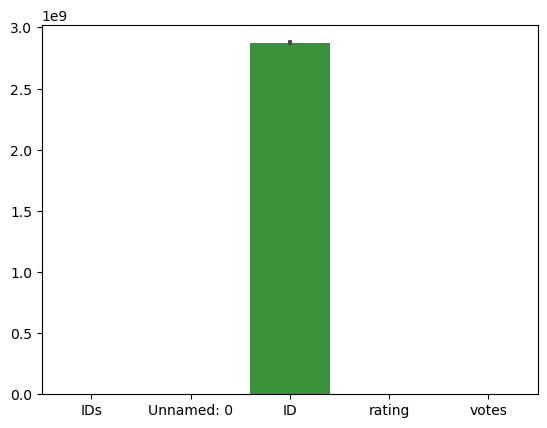

In [42]:
sns.barplot(combined)

<Axes: >

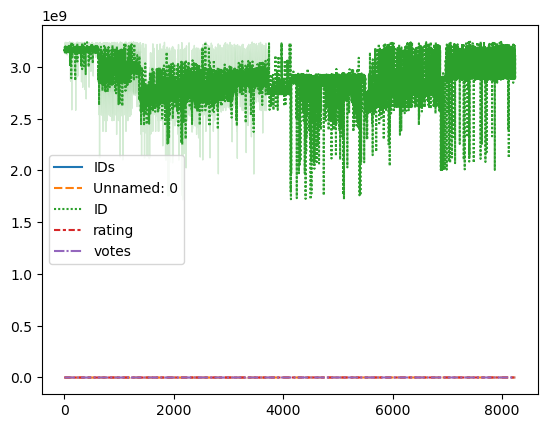

In [43]:
sns.lineplot(combined)

In [44]:
combined['IDs'].value_counts()

Series([], Name: IDs, dtype: int64)

In [47]:
combined['IDs'].unique()

array([nan])

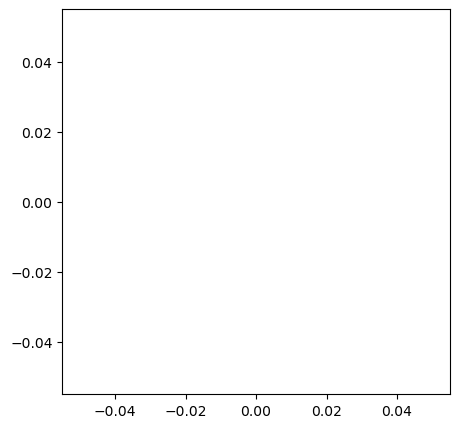

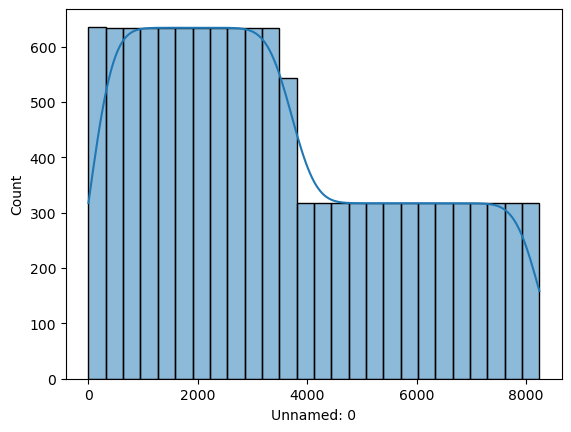

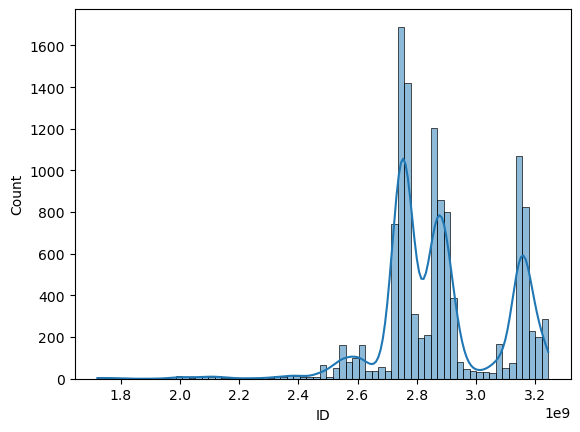

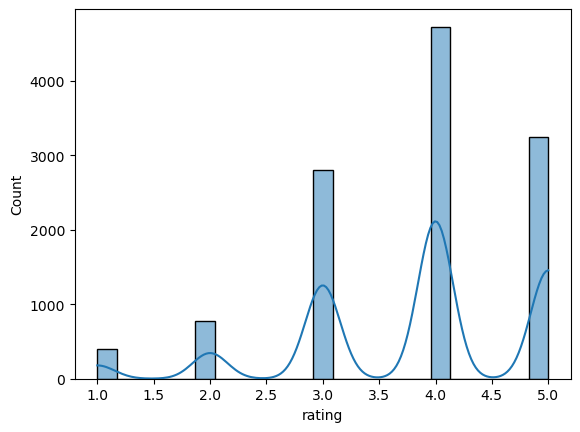

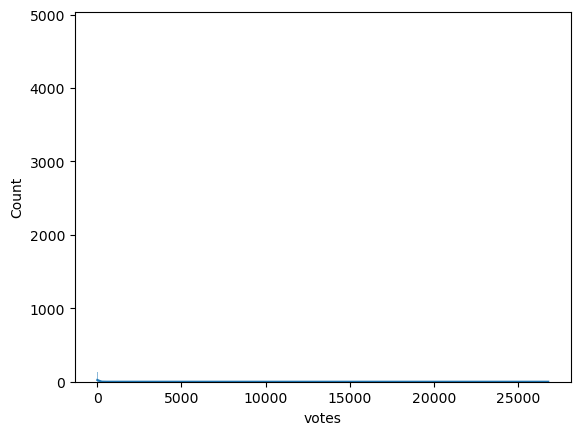

In [48]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

In [56]:
# Treating type of IDs
combined['IDs'].value_counts().head(9).index[1:]

Float64Index([], dtype='float64')

In [10]:
combined.head()

,IDs,Unnamed: 0,ID,comments,rating,votes
0,1,0,3144518654,虽然套路，但，真的好燃啊！！！后半段各种热泪瞬间。结尾收得很好，不用真的给一个奇迹瞬间，足够...,4.0,6845
1,2,1,3132673708,终于看到一部不是以孙悟空、哪吒为主角的优秀国漫了，居然还是现实主义题材的，太惊喜了。画风写实...,5.0,6375
2,3,2,3141125920,说句公道话，片方赚的每一分钱都应该拿出一半给周星驰，拿出两成给徐克李连杰，再拿出一成给马东。...,3.0,2968
3,4,3,3141155105,前半段配音烂、节奏烂、笑料烂，后半段老子一顿暴哭，燃死我得了，真的太顶了，简直是一杯呛鼻的烈...,4.0,5295
4,5,4,3136815531,是目前无限接近我心里当下该有的国漫样子——没有IP、没有过多对日美漫画的模仿、没有太多套路。...,5.0,7450


In [11]:
# Replacing weird values
combined = combined.applymap(lambda x: x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

In [12]:
combined.head()

,IDs,Unnamed: 0,ID,comments,rating,votes
0,1,0,3144518654,虽然套路，但，真的好燃啊！！！后半段各种热泪瞬间。结尾收得很好，不用真的给一个奇迹瞬间，足够...,4.0,6845
1,2,1,3132673708,终于看到一部不是以孙悟空、哪吒为主角的优秀国漫了，居然还是现实主义题材的，太惊喜了。画风写实...,5.0,6375
2,3,2,3141125920,说句公道话，片方赚的每一分钱都应该拿出一半给周星驰，拿出两成给徐克李连杰，再拿出一成给马东。...,3.0,2968
3,4,3,3141155105,前半段配音烂、节奏烂、笑料烂，后半段老子一顿暴哭，燃死我得了，真的太顶了，简直是一杯呛鼻的烈...,4.0,5295
4,5,4,3136815531,是目前无限接近我心里当下该有的国漫样子——没有IP、没有过多对日美漫画的模仿、没有太多套路。...,5.0,7450


In [13]:
# Treating type of IDs
combined['IDs'].value_counts().head(9).index[1:]

Int64Index([2482, 2470, 2471, 2472, 2473, 2474, 2475, 2476], dtype='int64')

In [17]:
# Rebuils type of IDs columns
for i in  combined['comments'].value_counts().head(9).index[1:]:
    combined[i]=combined['comments'].str.contains(i)

/tmp/ipykernel_32/1645798793.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined[i]=combined['comments'].str.contains(i)


In [20]:
combined.head()

,IDs,Unnamed: 0,ID,comments,rating,votes,放过自己 | 林小姐，演的真好。英文片名 little big woman 赞！| 7 (豆瓣到底什么时候可以十分制打分...),时间是与自己和解的良药。,适合过年全家一起看,5.5。不疼不痒，平庸之作。,孤岛电影，和解文学，如果说放过，几十年前就有机会，所有的细枝末节往好处讲是还原真实的无奈，另一个方面则是婆婆妈妈黏黏糊糊的故作坚强，这些比不过我对于快意恩仇这几个字的赞美。两星半。,有点像台湾的是枝裕和的，真正拍出了中国家庭那种味道和感觉，内里情感满满而又表面十分克制，渴望亲近却又无奈的疏离，层层的窗户纸看似一戳就破，实则经年累月早已成墙,这一部真是有回味，很多人打低分是因为觉得这部电影洗白渣男。其实这部剧远远超越了这种粗浅的理解，而是着重于对每个人的理解和同情，各人有各人的纠结，最后又达成某种程度的和解，与他人，与自己。,言情小说
0,1,0,3144518654,虽然套路，但，真的好燃啊！！！后半段各种热泪瞬间。结尾收得很好，不用真的给一个奇迹瞬间，足够...,4.0,6845,False,False,False,False,False,False,False,False
1,2,1,3132673708,终于看到一部不是以孙悟空、哪吒为主角的优秀国漫了，居然还是现实主义题材的，太惊喜了。画风写实...,5.0,6375,False,False,False,False,False,False,False,False
2,3,2,3141125920,说句公道话，片方赚的每一分钱都应该拿出一半给周星驰，拿出两成给徐克李连杰，再拿出一成给马东。...,3.0,2968,False,False,False,False,False,False,False,False
3,4,3,3141155105,前半段配音烂、节奏烂、笑料烂，后半段老子一顿暴哭，燃死我得了，真的太顶了，简直是一杯呛鼻的烈...,4.0,5295,False,False,False,False,False,False,False,False
4,5,4,3136815531,是目前无限接近我心里当下该有的国漫样子——没有IP、没有过多对日美漫画的模仿、没有太多套路。...,5.0,7450,False,False,False,False,False,False,False,False


In [21]:
# Treating type of comments
combined.groupby('comments')['IDs'].apply(lambda x:x.fillna(x.mode()[0]))

/tmp/ipykernel_32/1040434608.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  combined.groupby('comments')['IDs'].apply(lambda x:x.fillna(x.mode()[0]))


0          1
0          1
1          2
1          2
2          3
        ... 
8239    8240
8240    8241
8241    8242
8242    8243
8243    8244
Name: IDs, Length: 11958, dtype: int64

In [22]:
cat_cols

,comments
0,虽然套路，但，真的好燃啊！！！后半段各种热泪瞬间。结尾收得很好，不用真的给一个奇迹瞬间，足够...
1,终于看到一部不是以孙悟空、哪吒为主角的优秀国漫了，居然还是现实主义题材的，太惊喜了。画风写实...
2,说句公道话，片方赚的每一分钱都应该拿出一半给周星驰，拿出两成给徐克李连杰，再拿出一成给马东。...
3,前半段配音烂、节奏烂、笑料烂，后半段老子一顿暴哭，燃死我得了，真的太顶了，简直是一杯呛鼻的烈...
4,是目前无限接近我心里当下该有的国漫样子——没有IP、没有过多对日美漫画的模仿、没有太多套路。...
...,...
3709,新瓶装旧酒，画面表演都很优秀，就是故事太旧，离戏曲电影还差点意思
3710,给创新的艺术形式打五星
3711,值得鼓励，建议去电影院看，在家里坐不住。曾老师真的好美，好有味道～
3712,戏曲和CG好配


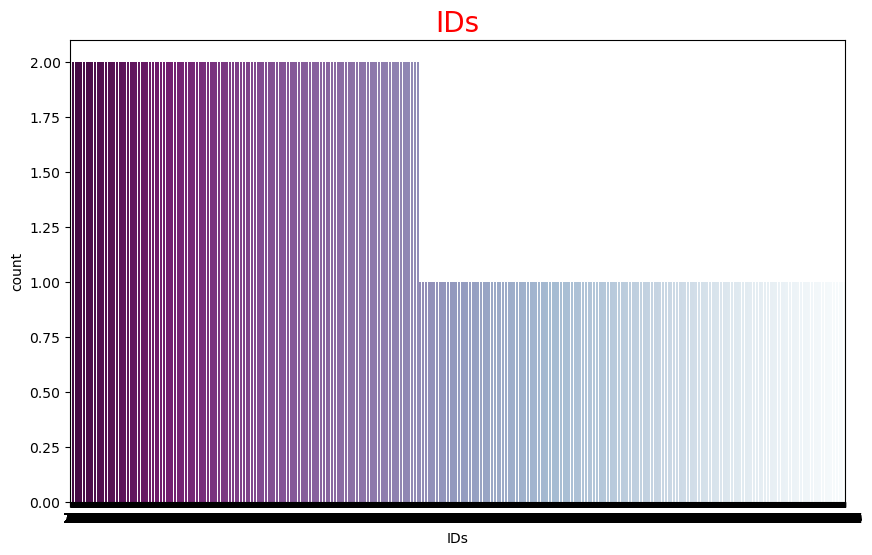

In [27]:
plt.figure(figsize=(10,6))
sns.countplot(data=combined,x='IDs',palette='BuPu_r')
plt.title('IDs',size=20,color='Red')
plt.show()

In [28]:
combined['IDs'].value_counts(normalize=True)*100

1       0.016725
2482    0.016725
2470    0.016725
2471    0.016725
2472    0.016725
          ...   
5230    0.008363
5231    0.008363
5232    0.008363
5233    0.008363
8244    0.008363
Name: IDs, Length: 8244, dtype: float64

In [30]:
train.shape[0]

8244

In [31]:
new_train=combined.iloc[0:train.shape[0],:]

In [33]:
new_test=combined.iloc[train.shape[0]:,:]

In [34]:
train.shape,new_train.shape,test.shape,new_test.shape

((8244, 6), (8244, 14), (3714, 5), (3714, 14))

In [36]:
import scipy.stats as stats

In [37]:
num_cols = combined.select_dtypes(include='number')
cat_cols= combined.select_dtypes(include='object')

In [38]:
sig_num=[]
for i in num_cols:
    zero=new_train.loc[new_train['IDs']==0,i]
    one=new_train.loc[new_train['IDs']==1,i]
    two=new_train.loc[new_train['IDs']==2,i]
    teststat,pval=stats.f_oneway(zero,one,two)
    if pval<0.05:
        sig_num.append(i)
        print(i)

/opt/conda/lib/python3.10/site-packages/scipy/stats/_stats_py.py:3861: DegenerateDataWarning: at least one input has length 0
  warnings.warn(stats.DegenerateDataWarning('at least one input '


In [41]:
sig_cat=[]
for i in cat_cols:
    a=pd.crosstab(new_train[i],new_train['IDs'])
    tstat,pval,dof,freq=stats.chi2_contingency(a)
    if pval<0.05:
        sig_cat.append(i)
        print(i)

In [42]:
train_new=new_train.loc[:,sig_cat+sig_num]

In [44]:
test_new=new_test.loc[:,sig_cat+sig_num]

In [ ]:
# Checking for multicollinearity

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [48]:
train_new

""
0
1
2
3
4
...
8239
8240
8241
8242


In [ ]:
# Scaling the col

In [54]:
scaling=[]

In [55]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [56]:
for i in scaling:
    train_new.loc[:,i]=scaler.fit_transform(pd.DataFrame(train_new.loc[:,i]))
    test_new.loc[:,i]=scaler.transform(pd.Dataframe(test_new.loc[:,i]))

In [57]:
train_new

""
0
1
2
3
4
...
8239
8240
8241
8242


In [58]:
test_new

""
0
1
2
3
4
...
3709
3710
3711
3712
